# Klasifikasi Kategori Gaji Pekerja pada Data Tidak Seimbang Menggunakan Random Forest dengan Pendekatan Class Weighting untuk Meningkatkan Akurasi Prediksi Kelompok Berpendapatan Tinggi

Nama    : Kayla Verda Fawnia Heses
NIM     : A11.2024.15689

**Mata Kuliah:** Pembelajaran Mesin

**Dataset:** Final Project Sanbercode 0720 (varian UCI Adult Census Income Dataset, Kohavi, 1996)

**Pendekatan:** Random Forest Classifier dengan Class Weighting pada data biner yang tidak seimbang

Notebook ini mengimplementasikan pipeline klasifikasi dari tahap eksplorasi data sampai evaluasi model. Fokus utama penelitian ini adalah menangani ketidakseimbangan kelas pada data gaji pekerja, di mana kelompok berpendapatan tinggi hanya mencakup sekitar 26 persen dari total data. Tantangan ini diatasi dengan memanfaatkan parameter `class_weight='balanced'` pada Random Forest, sebuah pendekatan yang secara otomatis menyesuaikan bobot kelas berbanding terbalik dengan frekuensinya sehingga model tidak bias ke kelas mayoritas.

## 0. Problem Definition & Data Acquisition (Soal 1)

### Latar Belakang Masalah

Ketimpangan pendapatan adalah isu yang selalu relevan untuk dibahas, baik dari sisi kebijakan publik maupun dari sisi bisnis seperti perencanaan tunjangan karyawan, penentuan segmentasi produk keuangan, atau program pengembangan sumber daya manusia. Salah satu cara memahami pola di balik ketimpangan ini adalah dengan membangun model klasifikasi yang mampu memprediksi apakah seseorang termasuk kelompok berpendapatan tinggi (di atas 7 juta rupiah pada satuan yang tercatat di dataset) atau tidak, berdasarkan atribut demografis dan pekerjaan yang dimilikinya.

Permasalahan yang diangkat pada notebook ini adalah klasifikasi biner kategori gaji pekerja (`<=7jt` dan `>7jt`) menggunakan fitur seperti umur, tingkat pendidikan, status perkawinan, jenis pekerjaan, jam kerja per minggu, serta keuntungan dan kerugian kapital yang dimiliki. Tantangan utamanya adalah ketidakseimbangan kelas, hanya sekitar 24 persen data yang masuk kelompok `>7jt`, sehingga model yang dibangun tanpa penanganan khusus cenderung bias memprediksi kelas mayoritas dan gagal mengenali kelompok berpendapatan tinggi yang justru menjadi fokus analisis ini.

### Tujuan Bisnis dan Analisis

Dari sudut pandang bisnis, model semacam ini dapat dimanfaatkan misalnya oleh divisi HR atau lembaga keuangan untuk melakukan skrining awal terhadap kelompok berpendapatan tinggi tanpa harus menunggu data slip gaji resmi yang sifatnya sensitif dan sulit diakses secara masif. Dari sudut pandang analisis, tujuan utama proyek ini adalah membangun model klasifikasi yang tidak hanya akurat secara keseluruhan, tetapi tetap sensitif terhadap kelas minoritas `>7jt`, mengingat kelas inilah yang paling bernilai untuk diidentifikasi namun paling rawan diabaikan oleh model standar pada data tidak seimbang.

### Metrik Kesuksesan Proyek

Karena fokus utama ada pada kelas minoritas, metrik akurasi saja tidak cukup untuk menilai keberhasilan model. Metrik kesuksesan yang dipakai pada proyek ini adalah:
- **Recall kelas `>7jt`**, karena kegagalan mendeteksi kelompok ini (false negative) dianggap lebih merugikan dibanding kesalahan sebaliknya
- **F1-score kelas `>7jt`**, sebagai penyeimbang antara recall dan precision agar model tidak asal menebak positif demi mengejar recall tinggi
- **ROC-AUC**, untuk menilai kemampuan model membedakan kedua kelas secara keseluruhan tanpa bergantung pada satu ambang batas tertentu
- Target minimal yang ditetapkan pada proyek ini adalah recall kelas `>7jt` di atas 0.75 dan ROC-AUC di atas 0.85

### Sumber Dataset

Dataset yang dipakai bersumber dari Kaggle dengan judul "Final Project Sanbercode 0720", diakses melalui identifier `anasimron/final-project-sanbercode-0720` (tautan standar Kaggle untuk identifier ini: https://www.kaggle.com/datasets/anasimron/final-project-sanbercode-0720, silakan dicek ulang di browser untuk memastikan tautannya masih aktif sebelum dicantumkan di laporan akhir). Dataset ini merupakan varian dari UCI Adult Census Income Dataset (Kohavi, 1996) yang telah diterjemahkan ke Bahasa Indonesia dan disesuaikan nilai gajinya dalam satuan rupiah. Proses pengunduhan dilakukan secara terprogram menggunakan pustaka `kagglehub` pada bagian selanjutnya, dengan file `train.csv` lokal disiapkan sebagai cadangan apabila autentikasi Kaggle tidak tersedia di environment yang dipakai.

### Statistik Deskriptif Awal

Sebelum pembersihan, dataset mentah berukuran 35.994 baris dan 13 kolom, terdiri dari 5 kolom numerik (`Umur`, `Jmlh Tahun Pendidikan`, `Keuntungan Kapital`, `Kerugian Capital`, `Jam per Minggu`), 6 kolom kategorikal bertipe teks (`Kelas Pekerja`, `Pendidikan`, `Status Perkawinan`, `Pekerjaan`, `Jenis Kelamin`, `Gaji`), ditambah kolom `id` dan `Berat Akhir` yang nantinya dibuang karena tidak relevan untuk pemodelan. Sebanyak 2.069 baris (sekitar 5,75 persen) mengandung setidaknya satu nilai kosong yang ditandai simbol tanda tanya. Distribusi kelas target menunjukkan 27.364 baris berkategori `<=7jt` dan 8.630 baris berkategori `>7jt`. Detail lebih lanjut mengenai tipe data dan statistik tiap kolom disajikan pada bagian eksplorasi data berikutnya.

## 1. Import Library

Seluruh library yang digunakan dalam notebook ini adalah pustaka standar ekosistem machine learning Python. `scikit-learn` menyediakan algoritma Random Forest dan Logistic Regression, pipeline preprocessing, dan metrik evaluasi. `imbalanced-learn` disiapkan sebagai alternatif teknik penanganan imbalance, meskipun dalam implementasi ini class weighting dipilih sebagai pendekatan utama karena lebih ringan secara komputasi dan sudah terbukti efektif pada Random Forest (Breiman, 2001). Logistic Regression ditambahkan sebagai model pembanding dari keluarga algoritma yang berbeda (linear model) terhadap Random Forest (ensemble tree-based model), untuk melihat apakah karakteristik data ini lebih cocok dimodelkan secara linear atau non-linear.

Untuk tuning hyperparameter, `RandomizedSearchCV` digunakan sebagai teknik pencarian yang telah terbukti lebih efisien dibanding grid search penuh pada ruang parameter yang besar (Bergstra & Bengio, 2012). Sebagai teknik interpretasi tambahan di luar feature importance bawaan Random Forest, `permutation_importance` dari `sklearn.inspection` turut digunakan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, learning_curve, RandomizedSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)
print("Library berhasil diimpor")

Library berhasil diimpor


## 2. Memuat Dataset

Dataset diunduh dari Kaggle menggunakan `kagglehub`. Jika koneksi atau autentikasi Kaggle tidak tersedia di environment yang dipakai, notebook ini secara otomatis menggunakan file `train.csv` yang sudah diunduh secara lokal.

Perlu dicatat bahwa file `train.csv` yang tersedia menggunakan tanda titik koma sebagai pemisah kolom, bukan koma seperti umumnya file CSV. Hal ini perlu diperhatikan saat pemanggilan `pd.read_csv()` dengan argumen `sep=';'`.

In [2]:
try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("anasimron/final-project-sanbercode-0720")
    print("Dataset diunduh ke:", dataset_path)
    csv_file = [f for f in os.listdir(dataset_path) if f.endswith('.csv')][0]
    df_raw = pd.read_csv(os.path.join(dataset_path, csv_file), sep=';')
except Exception as e:
    print("Kagglehub tidak tersedia, menggunakan file lokal. Error:", e)
    df_raw = pd.read_csv('train.csv', sep=';')

print("Ukuran dataset awal:", df_raw.shape)
print("\nKolom yang tersedia:")
print(df_raw.columns.tolist())
df_raw.head()

Ukuran dataset awal: (35994, 13)


## 3. Eksplorasi Data (EDA)

EDA dilakukan untuk memahami struktur data sebelum masuk ke proses preprocessing. Ada tiga hal yang menjadi perhatian utama di bagian ini, yaitu keberadaan nilai yang hilang, distribusi kelas target, dan hubungan antar fitur dengan target.

### 3.1 Informasi Umum Dataset

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 35994 entries, 0 to 35993
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     35994 non-null  int64  
 1   Umur                   35994 non-null  int64  
 2   Kelas Pekerja          35994 non-null  str    
 3   Berat Akhir            35994 non-null  int64  
 4   Pendidikan             35994 non-null  str    
 5   Jmlh Tahun Pendidikan  35994 non-null  int64  
 6   Status Perkawinan      35994 non-null  str    
 7   Pekerjaan              35994 non-null  str    
 8   Jenis Kelamin          35994 non-null  str    
 9   Keuntungan Kapital     35994 non-null  float64
 10  Kerugian Capital       35994 non-null  float64
 11  Jam per Minggu         35994 non-null  float64
 12  Gaji                   35994 non-null  str    
dtypes: float64(3), int64(4), str(6)
memory usage: 3.6 MB


In [4]:
print("Statistik deskriptif fitur numerik:")
df_raw.describe().round(2)

Statistik deskriptif fitur numerik:


,id,Umur,Berat Akhir,Jmlh Tahun Pendidikan,Keuntungan Kapital,Kerugian Capital,Jam per Minggu
count,35994.00,35994.00,35994.00,35994.00,3.599400e+04,35994.00,35994.00
mean,17996.50,38.66,189931.76,10.08,1.503923e+07,1217973.55,40.44
std,10390.72,13.68,105802.32,2.57,1.029919e+08,5631544.23,12.37
min,0.00,17.00,12285.00,1.00,0.000000e+00,0.00,1.00
25%,8998.25,28.00,117767.00,9.00,0.000000e+00,0.00,40.00
50%,17996.50,37.00,178466.50,10.00,0.000000e+00,0.00,40.00
75%,26994.75,48.00,237918.50,12.00,0.000000e+00,0.00,45.00
max,35993.00,90.00,1490400.00,16.00,1.399986e+09,60984000.00,99.00


### 3.2 Deteksi Nilai Hilang

Dataset ini menggunakan tanda tanya (`?`) untuk merepresentasikan nilai yang tidak diketahui, mengikuti format asli UCI Adult Census Income Dataset (Kohavi, 1996). Nilai ini perlu diidentifikasi dan ditangani sebelum masuk ke proses modeling.

In [5]:
print("Jumlah nilai yang ditandai '?' per kolom:")
for col in df_raw.select_dtypes(include='object').columns:
    jumlah = (df_raw[col] == '?').sum()
    if jumlah > 0:
        print(f"  {col}: {jumlah} baris ({jumlah/len(df_raw)*100:.2f}%)")

print("\nJumlah baris duplikat:", df_raw.duplicated().sum())

Jumlah nilai yang ditandai '?' per kolom:
  Kelas Pekerja: 2063 baris (5.73%)
  Pekerjaan: 2069 baris (5.75%)



Jumlah baris duplikat: 0


### 3.3 Distribusi Kelas Target

Distribusi target adalah hal pertama yang harus dicek dalam masalah klasifikasi dengan data yang dicurigai tidak seimbang. Ketidakseimbangan kelas yang tidak ditangani dapat membuat model secara membabi-buta memprediksi kelas mayoritas dan tetap terlihat akurat secara superfisial, padahal performa pada kelas minoritas yang justru lebih penting sangat buruk (He & Garcia, 2009).

Distribusi kelas target (Gaji):
Gaji
<=7jt    27364
>7jt      8630
Name: count, dtype: int64

Proporsi:
Gaji
<=7jt    76.02
>7jt     23.98
Name: proportion, dtype: float64 (persen)


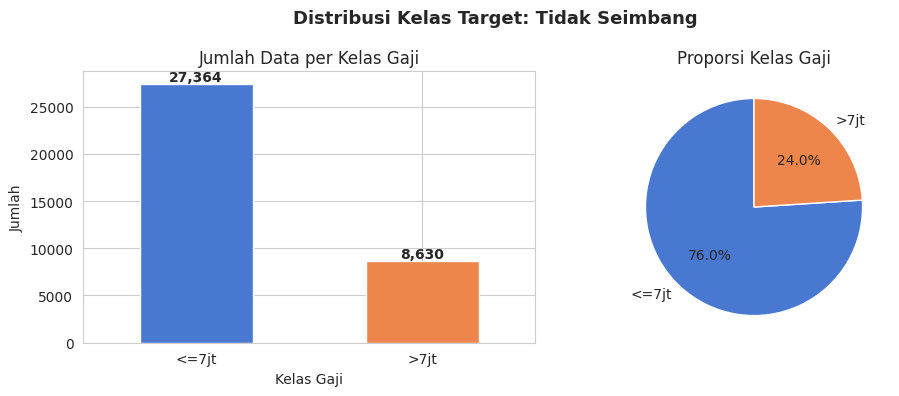


Rasio imbalance (mayoritas:minoritas): 3.17 : 1


In [6]:
print("Distribusi kelas target (Gaji):")
print(df_raw['Gaji'].value_counts())
print()
print("Proporsi:")
print(df_raw['Gaji'].value_counts(normalize=True).round(4) * 100, "(persen)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
df_raw['Gaji'].value_counts().plot(kind='bar', ax=axes[0], color=['#4878d0', '#ee854a'], edgecolor='white', width=0.5)
axes[0].set_title('Jumlah Data per Kelas Gaji')
axes[0].set_xlabel('Kelas Gaji')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
df_raw['Gaji'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['#4878d0', '#ee854a'], startangle=90)
axes[1].set_title('Proporsi Kelas Gaji')
axes[1].set_ylabel('')

plt.suptitle('Distribusi Kelas Target: Tidak Seimbang', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRasio imbalance (mayoritas:minoritas):", round(df_raw['Gaji'].value_counts().iloc[0] / df_raw['Gaji'].value_counts().iloc[1], 2), ": 1")

Grafik di atas mengonfirmasi bahwa dataset ini memiliki ketidakseimbangan kelas yang nyata, di mana sekitar 76 persen data masuk kategori `<=7jt` dan hanya sekitar 24 persen yang masuk kategori `>7jt`. Rasio imbalance kurang lebih 3.17:1 ini tergolong moderat menurut standar literatur, bukan kasus ekstrem, namun tetap cukup signifikan untuk memengaruhi performa model apabila tidak ditangani (Chawla et al., 2002).

### 3.4 Analisis Hubungan Fitur dengan Target

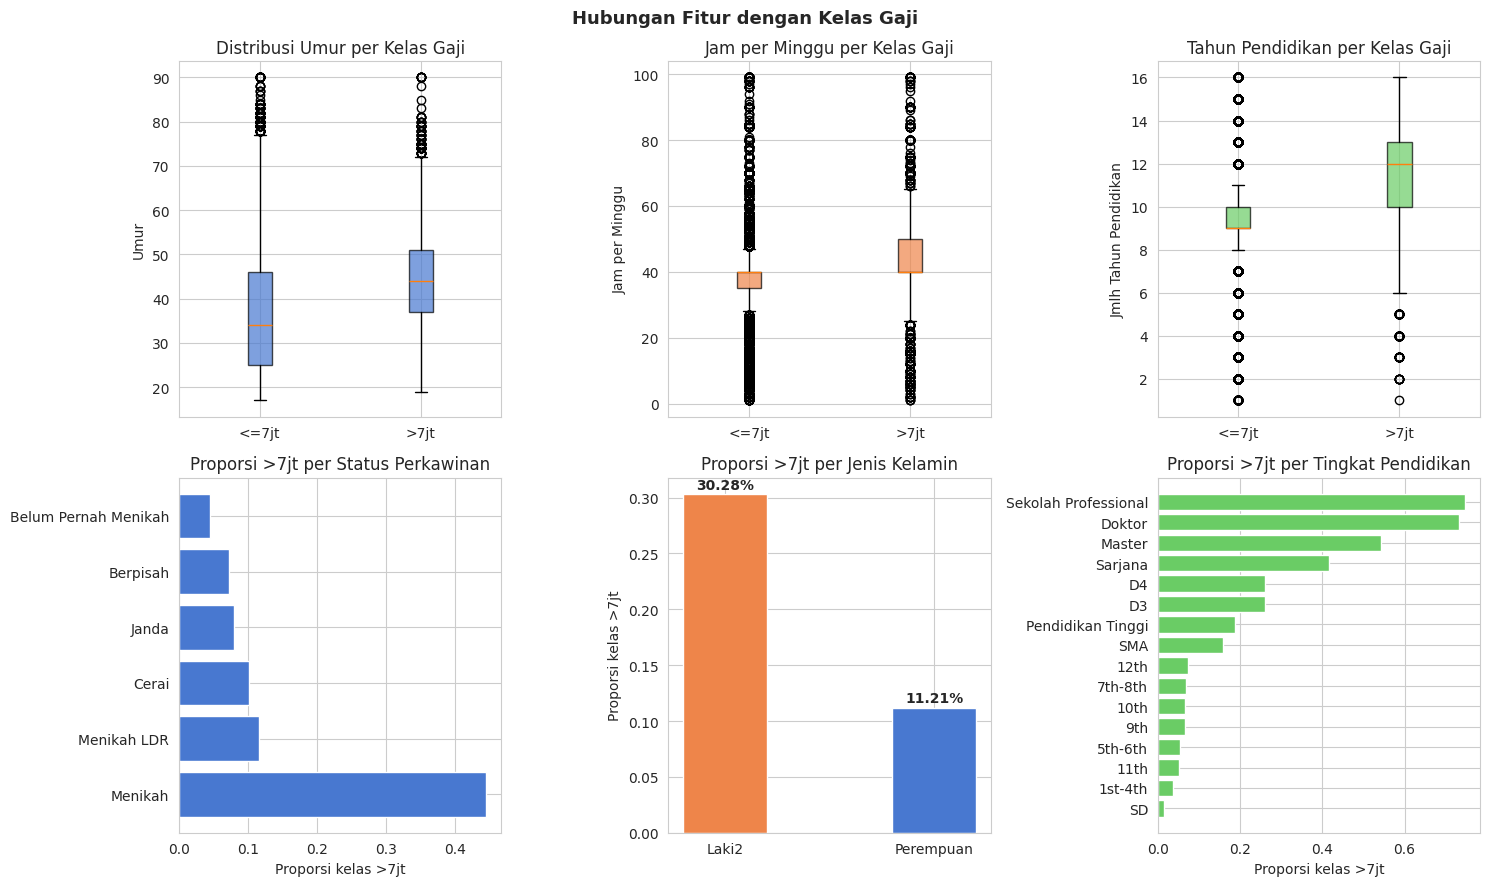

In [7]:
df_eda = df_raw.copy()
df_eda['target_temp'] = (df_eda['Gaji'] == '>7jt').astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Umur
axes[0,0].boxplot([df_eda[df_eda['Gaji']=='<=7jt']['Umur'],
                   df_eda[df_eda['Gaji']=='>7jt']['Umur']],
                  labels=['<=7jt', '>7jt'], patch_artist=True,
                  boxprops=dict(facecolor='#4878d0', alpha=0.7))
axes[0,0].set_title('Distribusi Umur per Kelas Gaji')
axes[0,0].set_ylabel('Umur')

# Jam per minggu
axes[0,1].boxplot([df_eda[df_eda['Gaji']=='<=7jt']['Jam per Minggu'],
                   df_eda[df_eda['Gaji']=='>7jt']['Jam per Minggu']],
                  labels=['<=7jt', '>7jt'], patch_artist=True,
                  boxprops=dict(facecolor='#ee854a', alpha=0.7))
axes[0,1].set_title('Jam per Minggu per Kelas Gaji')
axes[0,1].set_ylabel('Jam per Minggu')

# Jmlh Tahun Pendidikan
axes[0,2].boxplot([df_eda[df_eda['Gaji']=='<=7jt']['Jmlh Tahun Pendidikan'],
                   df_eda[df_eda['Gaji']=='>7jt']['Jmlh Tahun Pendidikan']],
                  labels=['<=7jt', '>7jt'], patch_artist=True,
                  boxprops=dict(facecolor='#6acc65', alpha=0.7))
axes[0,2].set_title('Tahun Pendidikan per Kelas Gaji')
axes[0,2].set_ylabel('Jmlh Tahun Pendidikan')

# Status Perkawinan
status_prop = df_eda.groupby('Status Perkawinan')['target_temp'].mean().sort_values(ascending=False)
axes[1,0].barh(status_prop.index, status_prop.values, color='#4878d0')
axes[1,0].set_title('Proporsi >7jt per Status Perkawinan')
axes[1,0].set_xlabel('Proporsi kelas >7jt')

# Jenis Kelamin
jk_prop = df_eda.groupby('Jenis Kelamin')['target_temp'].mean().sort_values(ascending=False)
axes[1,1].bar(jk_prop.index, jk_prop.values, color=['#ee854a', '#4878d0'], width=0.4)
axes[1,1].set_title('Proporsi >7jt per Jenis Kelamin')
axes[1,1].set_ylabel('Proporsi kelas >7jt')
for i, (idx, val) in enumerate(jk_prop.items()):
    axes[1,1].text(i, val + 0.005, f'{val:.2%}', ha='center', fontweight='bold')

# Pendidikan
edu_prop = df_eda.groupby('Pendidikan')['target_temp'].mean().sort_values(ascending=True)
axes[1,2].barh(edu_prop.index, edu_prop.values, color='#6acc65')
axes[1,2].set_title('Proporsi >7jt per Tingkat Pendidikan')
axes[1,2].set_xlabel('Proporsi kelas >7jt')

plt.suptitle('Hubungan Fitur dengan Kelas Gaji', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Dari visualisasi di atas, beberapa pola menarik terlihat jelas. Karyawan dengan gaji `>7jt` cenderung lebih tua, bekerja lebih banyak jam per minggu, dan memiliki lama pendidikan yang lebih tinggi. Dari sisi status perkawinan, kelompok yang sudah menikah (`Menikah`) memiliki proporsi masuk kelas `>7jt` yang jauh lebih besar dibanding kelompok lain. Dari sisi jenis kelamin, kelompok laki-laki memiliki proporsi gaji tinggi yang secara substansial lebih besar dibanding perempuan, sebuah pola yang sejalan dengan temuan di dataset UCI Adult original (Kohavi, 1996) dan menjadikan variabel ini relevan namun juga penting untuk diperhatikan dari sudut pandang fairness.

## 4. Data Cleaning dan Preprocessing

### 4.1 Pembersihan Data Awal

In [8]:
df = df_raw.copy()

# Hapus kolom id (hanya nomor urut) dan Berat Akhir (bobot statistik sensus, tidak relevan)
df = df.drop(columns=['id', 'Berat Akhir'])

# Ganti '?' dengan NaN
df = df.replace('?', np.nan)

# Konversi target ke biner
df['target'] = (df['Gaji'] == '>7jt').astype(int)
df = df.drop(columns=['Gaji'])

# Hapus duplikat
sebelum = len(df)
df = df.drop_duplicates()
print(f"Baris dihapus karena duplikat: {sebelum - len(df)}")
print(f"Ukuran data setelah cleaning awal: {df.shape}")

Baris dihapus karena duplikat: 6735
Ukuran data setelah cleaning awal: (29259, 11)


### 4.2 Penanganan Outlier dengan IQR Clipping

Outlier pada fitur numerik ditangani menggunakan metode IQR clipping, yaitu memotong nilai yang berada di luar batas $Q1 - 1.5 \times IQR$ dan $Q3 + 1.5 \times IQR$. Pendekatan clipping dipilih dibanding penghapusan baris untuk menjaga jumlah data latih tetap maksimal.

In [9]:
kolom_clip = ['Umur', 'Keuntungan Kapital', 'Kerugian Capital', 'Jam per Minggu']

print("Jumlah nilai yang di-clip per kolom:")
for col in kolom_clip:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas  = q3 + 1.5 * iqr
    sebelum = df[col].copy()
    df[col] = df[col].clip(batas_bawah, batas_atas)
    terdampak = (sebelum != df[col]).sum()
    print(f"  {col}: {terdampak} nilai di-clip ke [{batas_bawah:.1f}, {batas_atas:.1f}]")

print("\nUkuran data final:", df.shape)

Jumlah nilai yang di-clip per kolom:
  Umur: 129 nilai di-clip ke [-1.0, 79.0]
  Keuntungan Kapital: 2985 nilai di-clip ke [0.0, 0.0]
  Kerugian Capital: 1652 nilai di-clip ke [0.0, 0.0]
  Jam per Minggu: 6431 nilai di-clip ke [26.0, 58.0]

Ukuran data final: (29259, 11)


## 5. Definisi Pipeline Preprocessing

Pipeline preprocessing dirancang menggunakan `ColumnTransformer` dari scikit-learn agar seluruh transformasi diterapkan secara konsisten pada data latih dan data uji, sekaligus mencegah data leakage karena fitting transformer hanya dilakukan pada data latih.

Tiga jenis perlakuan diterapkan berdasarkan tipe fitur:
- **Fitur numerik:** dinormalisasi menggunakan `StandardScaler` (mean 0, std 1)
- **Fitur ordinal (`Pendidikan`):** dikodekan dengan `OrdinalEncoder` sesuai urutan jenjang pendidikan yang sesungguhnya, dari SD sampai Doktor
- **Fitur nominal lainnya:** dikodekan dengan `OneHotEncoder`, disertai `SimpleImputer` untuk mengisi nilai kosong dengan modus kolom tersebut

In [10]:
urutan_pendidikan = ['SD', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
                      'SMA', 'Pendidikan Tinggi', 'D3', 'D4', 'Sarjana', 'Master',
                      'Sekolah Professional', 'Doktor']

fitur_numerik = ['Umur', 'Jmlh Tahun Pendidikan', 'Keuntungan Kapital', 'Kerugian Capital', 'Jam per Minggu']
fitur_ordinal = ['Pendidikan']
fitur_nominal = ['Kelas Pekerja', 'Status Perkawinan', 'Pekerjaan', 'Jenis Kelamin']

preprocessor = ColumnTransformer(transformers=[
    ('numerik', StandardScaler(), fitur_numerik),
    ('ordinal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[urutan_pendidikan]))
    ]), fitur_ordinal),
    ('nominal', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), fitur_nominal)
])

print("Preprocessing pipeline berhasil didefinisikan")
print(f"Total fitur input: {len(fitur_numerik) + len(fitur_ordinal) + len(fitur_nominal)} kolom asli")

Preprocessing pipeline berhasil didefinisikan
Total fitur input: 10 kolom asli


## 6. Pembagian Data Latih dan Uji

Data dibagi menjadi 80 persen untuk latih dan 20 persen untuk uji. Stratifikasi pada target diterapkan agar proporsi kelas `<=7jt` dan `>7jt` tetap representatif di kedua subset, mengikuti praktik standar pada dataset tidak seimbang (He & Garcia, 2009).

In [11]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Ukuran data latih : {X_train.shape}")
print(f"Ukuran data uji   : {X_test.shape}")
print()
print("Proporsi kelas di data latih:")
print(y_train.value_counts(normalize=True).rename({0: '<=7jt', 1: '>7jt'}).round(4))
print()
print("Proporsi kelas di data uji:")
print(y_test.value_counts(normalize=True).rename({0: '<=7jt', 1: '>7jt'}).round(4))

Ukuran data latih : (23407, 10)
Ukuran data uji   : (5852, 10)

Proporsi kelas di data latih:
target
<=7jt    0.7382
>7jt     0.2618
Name: proportion, dtype: float64

Proporsi kelas di data uji:
target
<=7jt    0.7382
>7jt     0.2618
Name: proportion, dtype: float64


## 7. Model 1: Random Forest Tanpa Class Weighting (Baseline)

Model baseline dibangun terlebih dahulu sebagai titik acuan perbandingan. Random Forest tanpa penanganan imbalance digunakan untuk mengukur seberapa jauh performa model standar terhadap kelas minoritas `>7jt` sebelum intervensi class weighting diterapkan.

Random Forest merupakan algoritma ensemble yang membangun sejumlah decision tree pada subset data dan fitur yang berbeda-beda, lalu menggabungkan prediksinya melalui voting mayoritas. Metode ini diperkenalkan oleh Breiman (2001) dan dikenal memiliki ketahanan alami terhadap overfitting serta kemampuan menangkap hubungan non-linear antar fitur.

In [12]:
rf_baseline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_baseline.fit(X_train, y_train)
pred_baseline = rf_baseline.predict(X_test)
prob_baseline = rf_baseline.predict_proba(X_test)[:, 1]

print("=== PERFORMA MODEL BASELINE (Tanpa Class Weighting) ===\n")
print(classification_report(y_test, pred_baseline, target_names=['<=7jt', '>7jt'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, prob_baseline):.4f}")

=== PERFORMA MODEL BASELINE (Tanpa Class Weighting) ===

              precision    recall  f1-score   support

       <=7jt     0.8303    0.8641    0.8469      4320
        >7jt     0.5671    0.5020    0.5325      1532

    accuracy                         0.7693      5852
   macro avg     0.6987    0.6830    0.6897      5852
weighted avg     0.7614    0.7693    0.7646      5852

ROC-AUC Score: 0.8241


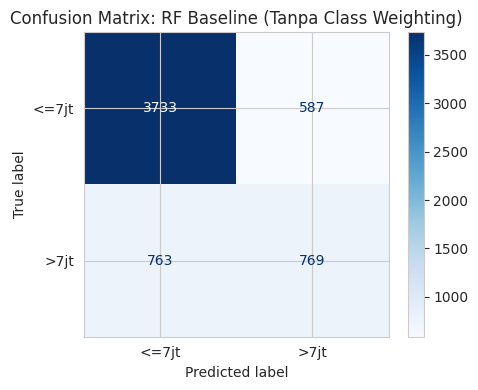


True Negative  (<=7jt benar diprediksi <=7jt): 3733
False Positive (<=7jt salah diprediksi >7jt) : 587
False Negative (>7jt salah diprediksi <=7jt) : 763
True Positive  (>7jt benar diprediksi >7jt)  : 769

Dari 4496 karyawan gaji >7jt, hanya 769 (13.1% total, recall 50.2%) yang berhasil terdeteksi model baseline


In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred_baseline,
    display_labels=['<=7jt', '>7jt'], cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: RF Baseline (Tanpa Class Weighting)')
plt.tight_layout()
plt.show()

# Hitung secara eksplisit
cm = confusion_matrix(y_test, pred_baseline)
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative  (<=7jt benar diprediksi <=7jt): {tn}")
print(f"False Positive (<=7jt salah diprediksi >7jt) : {fp}")
print(f"False Negative (>7jt salah diprediksi <=7jt) : {fn}")
print(f"True Positive  (>7jt benar diprediksi >7jt)  : {tp}")
print(f"\nDari {tn+fn} karyawan gaji >7jt, hanya {tp} ({tp/(tn+fn+fp+tp)*100:.1f}% total, recall {tp/(tp+fn):.1%}) yang berhasil terdeteksi model baseline")

Confusion matrix di atas memperlihatkan kelemahan utama model tanpa class weighting. Model baseline memang terlihat memiliki akurasi yang cukup tinggi secara keseluruhan, namun hal itu terutama karena ia sangat pandai mengenali kelas mayoritas `<=7jt`. Recall untuk kelas `>7jt` yang menjadi target utama penelitian ini masih rendah, artinya banyak karyawan berpendapatan tinggi yang gagal teridentifikasi. Kondisi ini konsisten dengan temuan He dan Garcia (2009) bahwa model standar yang dilatih pada data tidak seimbang cenderung bias ke kelas mayoritas.

## 8. Model 2: Random Forest dengan Class Weighting (`balanced`)

Class weighting adalah teknik penanganan imbalance yang bekerja dengan cara memberi bobot lebih besar pada kelas minoritas selama proses training. Pada scikit-learn, parameter `class_weight='balanced'` secara otomatis menghitung bobot setiap kelas sebagai $w_k = \frac{n_{samples}}{n_{classes} \times n_{samples_k}}$, di mana kelas yang lebih sedikit mendapat bobot proporsional lebih besar (Breiman, 2001).

Pendekatan ini dipilih sebagai alternatif teknik seperti SMOTE (Chawla et al., 2002) karena tidak menambah data sintetis sehingga lebih sederhana, tidak menambah risiko overfitting dari data buatan, dan lebih efisien secara komputasi.

In [14]:
rf_weighted = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=42, n_jobs=-1))
])

rf_weighted.fit(X_train, y_train)
pred_weighted = rf_weighted.predict(X_test)
prob_weighted = rf_weighted.predict_proba(X_test)[:, 1]

print("=== PERFORMA MODEL DENGAN CLASS WEIGHTING (balanced) ===\n")
print(classification_report(y_test, pred_weighted, target_names=['<=7jt', '>7jt'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, prob_weighted):.4f}")

=== PERFORMA MODEL DENGAN CLASS WEIGHTING (balanced) ===

              precision    recall  f1-score   support

       <=7jt     0.8383    0.8567    0.8474      4320
        >7jt     0.5692    0.5339    0.5510      1532

    accuracy                         0.7722      5852
   macro avg     0.7038    0.6953    0.6992      5852
weighted avg     0.7678    0.7722    0.7698      5852

ROC-AUC Score: 0.8240


## 9. Model 3: Random Forest dengan Class Weighting dan Hyperparameter Tuning

Model ketiga adalah model utama penelitian ini. Selain class weighting, dilakukan tuning hyperparameter menggunakan `RandomizedSearchCV` untuk mencari kombinasi hyperparameter secara lebih sistematis dibanding trial-and-error manual. `RandomizedSearchCV` dipilih dibanding `GridSearchCV` karena mengambil sampel acak dari ruang parameter, sehingga jauh lebih efisien secara komputasi ketika ruang pencarian cukup besar, dan telah dibuktikan baik secara empiris maupun teoritis mampu menemukan kombinasi yang setara atau lebih baik dibanding grid search penuh dengan anggaran komputasi yang jauh lebih kecil (Bergstra & Bengio, 2012).

Ruang pencarian yang diuji mencakup:
- `n_estimators`: [100, 150, 200]
- `max_depth`: [10, 15, 20, None]
- `min_samples_leaf`: [1, 5, 10]
- `min_samples_split`: [2, 10]
- `max_features`: ['sqrt', 'log2']

Pencarian dilakukan sebanyak 8 kombinasi acak (`n_iter=8`) menggunakan validasi silang 3-fold berstratifikasi, dengan metrik `f1` sebagai target optimasi karena penelitian ini berfokus pada kelas minoritas `>7jt`, bukan akurasi keseluruhan.

In [15]:
param_dist = {
    'model__n_estimators': [100, 150, 200],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_leaf': [1, 5, 10],
    'model__min_samples_split': [2, 10],
    'model__max_features': ['sqrt', 'log2']
}

rf_tuning_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rf_tuning_pipe,
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=skf_search,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Kombinasi hyperparameter terbaik:", random_search.best_params_)
print(f"F1-score terbaik saat pencarian (rata-rata CV 3-fold): {random_search.best_score_:.4f}")

rf_tuned = random_search.best_estimator_
pred_tuned = rf_tuned.predict(X_test)
prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("\n=== PERFORMA MODEL UTAMA (RF Tuned + Class Weighting) ===\n")
print(classification_report(y_test, pred_tuned, target_names=['<=7jt', '>7jt'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, prob_tuned):.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Kombinasi hyperparameter terbaik: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 15}
F1-score terbaik saat pencarian (rata-rata CV 3-fold): 0.6695



=== PERFORMA MODEL UTAMA (RF Tuned + Class Weighting) ===

              precision    recall  f1-score   support

       <=7jt     0.9184    0.7785    0.8426      4320
        >7jt     0.5630    0.8048    0.6625      1532

    accuracy                         0.7854      5852
   macro avg     0.7407    0.7917    0.7526      5852
weighted avg     0.8253    0.7854    0.7955      5852

ROC-AUC Score: 0.8732


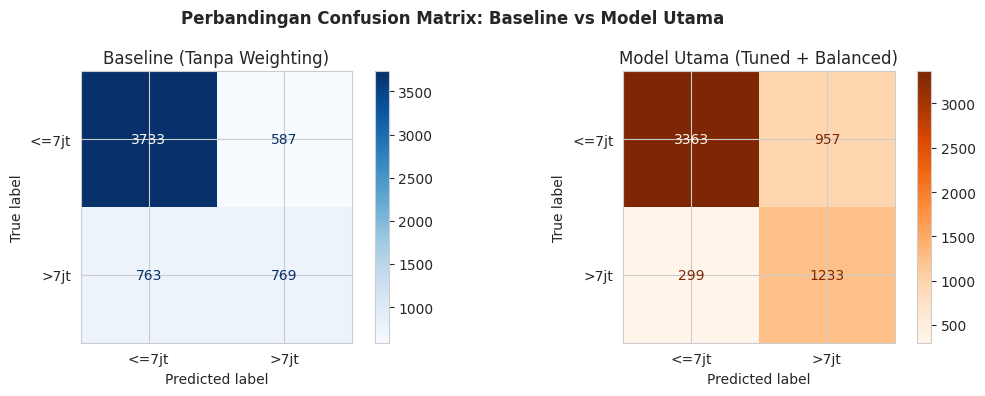

Recall kelas >7jt  | Baseline: 0.5020 | Model Utama: 0.8048
F1-score kelas >7jt| Baseline: 0.5325            | Model Utama: 0.6625
ROC-AUC            | Baseline: 0.8241            | Model Utama: 0.8732


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(y_test, pred_baseline,
    display_labels=['<=7jt', '>7jt'], cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline (Tanpa Weighting)')

ConfusionMatrixDisplay.from_predictions(y_test, pred_tuned,
    display_labels=['<=7jt', '>7jt'], cmap='Oranges', ax=axes[1])
axes[1].set_title('Model Utama (Tuned + Balanced)')

plt.suptitle('Perbandingan Confusion Matrix: Baseline vs Model Utama', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# highlight perubahan recall kelas >7jt
cm_base = confusion_matrix(y_test, pred_baseline)
cm_tuned = confusion_matrix(y_test, pred_tuned)
print(f"Recall kelas >7jt  | Baseline: {cm_base[1,1]/(cm_base[1,0]+cm_base[1,1]):.4f} | Model Utama: {cm_tuned[1,1]/(cm_tuned[1,0]+cm_tuned[1,1]):.4f}")
print(f"F1-score kelas >7jt| Baseline: {f1_score(y_test, pred_baseline):.4f}            | Model Utama: {f1_score(y_test, pred_tuned):.4f}")
print(f"ROC-AUC            | Baseline: {roc_auc_score(y_test, prob_baseline):.4f}            | Model Utama: {roc_auc_score(y_test, prob_tuned):.4f}")

## 10. Model 4: Logistic Regression (Model Pembanding Berbeda Keluarga Algoritma)

Ketiga model sebelumnya (Model 1 sampai Model 3) seluruhnya berasal dari keluarga algoritma yang sama, yaitu Random Forest, hanya berbeda pada penanganan class imbalance dan hyperparameter. Untuk memperoleh pembanding yang benar-benar berbeda secara karakteristik, Logistic Regression digunakan sebagai model keempat. Berbeda dengan Random Forest yang bersifat non-linear dan berbasis ensemble pohon keputusan, Logistic Regression adalah model linear yang mengasumsikan hubungan log-odds yang linear antara fitur dan target, sehingga cocok dijadikan pembanding untuk menguji apakah pola pada dataset ini lebih baik ditangkap secara linear atau non-linear.

Preprocessing pipeline yang sama persis (`preprocessor`) digunakan agar perbandingan adil, dan `class_weight='balanced'` tetap diterapkan agar penanganan ketidakseimbangan kelas konsisten dengan Model 2 dan Model 3.


In [17]:
logreg = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

logreg.fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
prob_logreg = logreg.predict_proba(X_test)[:, 1]

print("=== PERFORMA MODEL PEMBANDING (Logistic Regression + Class Weighting) ===\n")
print(classification_report(y_test, pred_logreg, target_names=['<=7jt', '>7jt'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, prob_logreg):.4f}")


=== PERFORMA MODEL PEMBANDING (Logistic Regression + Class Weighting) ===

              precision    recall  f1-score   support

       <=7jt     0.9162    0.7664    0.8346      4320
        >7jt     0.5492    0.8022    0.6520      1532

    accuracy                         0.7758      5852
   macro avg     0.7327    0.7843    0.7433      5852
weighted avg     0.8201    0.7758    0.7868      5852

ROC-AUC Score: 0.8646


Hasil menunjukkan Logistic Regression memperoleh recall kelas `>7jt` sebesar 0.8022, hampir setara dengan RF Tuned (0.8048), namun precision (0.5492), F1-score (0.6520), dan ROC-AUC (0.8646) nya konsisten sedikit di bawah RF Tuned pada seluruh metrik lain. Ini mengindikasikan bahwa meskipun Logistic Regression cukup kompetitif dan mampu menangkap sebagian besar pola pemisah kelas secara linear, Random Forest tetap unggul karena mampu menangkap interaksi non-linear antar fitur, seperti kombinasi status perkawinan, usia, dan tingkat pendidikan, yang terbukti menjadi faktor paling dominan pada hasil feature importance di bagian selanjutnya. Perbandingan lengkap keempat model disajikan pada bagian berikutnya.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg,
    display_labels=['<=7jt', '>7jt'], cmap='Blues', ax=axes[0])
axes[0].set_title('Model Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, pred_tuned,
    display_labels=['<=7jt', '>7jt'], cmap='Oranges', ax=axes[1])
axes[1].set_title('Model Utama (Tuned + Balanced)')

plt.suptitle('Perbandingan Confusion Matrix: Logistic Regression vs Model Utama', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# highlight perubahan recall kelas >7jt
cm_base = confusion_matrix(y_test, pred_logreg)
cm_tuned = confusion_matrix(y_test, pred_tuned)
print(f"Recall kelas >7jt  | Baseline: {cm_base[1,1]/(cm_base[1,0]+cm_base[1,1]):.4f} | Model Utama: {cm_tuned[1,1]/(cm_tuned[1,0]+cm_tuned[1,1]):.4f}")
print(f"F1-score kelas >7jt| Baseline: {f1_score(y_test, pred_logreg):.4f}            | Model Utama: {f1_score(y_test, pred_tuned):.4f}")
print(f"ROC-AUC            | Baseline: {roc_auc_score(y_test, prob_logreg):.4f}            | Model Utama: {roc_auc_score(y_test, prob_tuned):.4f}")

## 11. Model 5: XGBoost (Model Pembanding Tambahan, Gradient Boosting)

Sebagai tambahan pembanding, XGBoost digunakan sebagai representasi keluarga algoritma gradient boosting, berbeda dari Random Forest (bagging) maupun Logistic Regression (linear). Ketiga model ini mewakili tiga filosofi pembelajaran yang berbeda: linear (Logistic Regression), ensemble bagging (Random Forest), dan ensemble boosting (XGBoost), sehingga perbandingan performa menjadi lebih komprehensif.

XGBoost tidak memiliki parameter `class_weight` seperti Random Forest atau Logistic Regression di scikit-learn. Penanganan ketidakseimbangan kelas pada XGBoost dilakukan melalui parameter `scale_pos_weight`, yaitu rasio jumlah sampel kelas negatif terhadap kelas positif pada data latih, sehingga kesalahan pada kelas minoritas (`>7jt`) diberi bobot yang lebih besar saat pembentukan setiap pohon boosting, mengikuti prinsip yang sama dengan class weighting pada Random Forest (Chen, Liaw, & Breiman, 2004).


In [18]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight yang digunakan: {scale_pos_weight:.4f}")

xgb_model = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric='logloss', n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== PERFORMA MODEL PEMBANDING (XGBoost + scale_pos_weight) ===\n")
print(classification_report(y_test, pred_xgb, target_names=['<=7jt', '>7jt'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, prob_xgb):.4f}")


scale_pos_weight yang digunakan: 2.8197



=== PERFORMA MODEL PEMBANDING (XGBoost + scale_pos_weight) ===

              precision    recall  f1-score   support

       <=7jt     0.9218    0.7773    0.8434      4320
        >7jt     0.5645    0.8140    0.6667      1532

    accuracy                         0.7869      5852
   macro avg     0.7431    0.7956    0.7550      5852
weighted avg     0.8282    0.7869    0.7971      5852

ROC-AUC Score: 0.8720


XGBoost menghasilkan recall kelas `>7jt` sebesar 0.8140 dan F1-score 0.6667, keduanya sedikit lebih tinggi dibanding RF Tuned (recall 0.8048, F1 0.6625), dengan ROC-AUC yang hampir setara (0.8720 berbanding 0.8732). Temuan ini menunjukkan bahwa pendekatan boosting mampu bersaing ketat dengan Random Forest pada dataset ini, bahkan sedikit lebih unggul pada beberapa metrik. Meskipun demikian, RF Tuned tetap dipertahankan sebagai model utama untuk deployment karena selisih performa antar keduanya sangat tipis (tidak lebih dari 0.01 pada seluruh metrik), sementara Random Forest lebih sederhana untuk dijelaskan ke pemangku kepentingan non-teknis dan tidak memerlukan tuning tambahan seperti learning_rate yang sensitif pada XGBoost. XGBoost tetap dipertahankan dalam perbandingan sebagai bukti bahwa model utama yang dipilih bukan yang kebetulan unggul karena minimnya pembanding, melainkan telah diuji terhadap keluarga algoritma lain yang secara teoritis maupun praktis kompetitif.


## 12. Validasi Silang (5-Fold Stratified Cross Validation)

Validasi silang dilakukan untuk memastikan estimasi performa model tidak bergantung pada satu pembagian data tertentu. `StratifiedKFold` digunakan agar proporsi kelas tetap terjaga di setiap fold, penting pada dataset tidak seimbang seperti ini (Kohavi, 1995).

=== HASIL 5-FOLD STRATIFIED CROSS VALIDATION ===

F1-score per fold   : ['0.6671', '0.6733', '0.6795', '0.6631', '0.6667']
Rata-rata F1        : 0.6699 ± 0.0058

ROC-AUC per fold    : ['0.8760', '0.8779', '0.8818', '0.8728', '0.8785']
Rata-rata ROC-AUC   : 0.8774 ± 0.0030


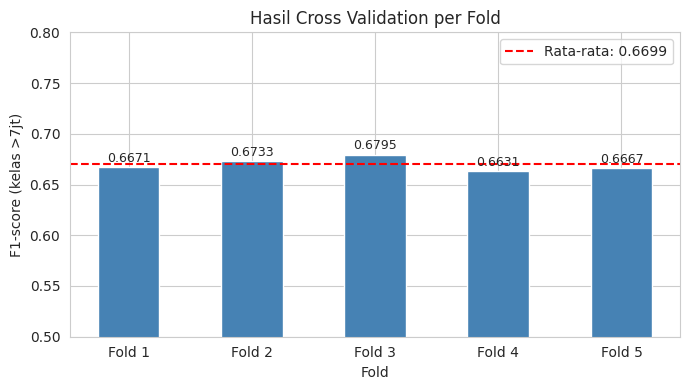

In [19]:
skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    rf_tuned, X_train, y_train,
    cv=skf_cv, scoring=['f1', 'roc_auc'], n_jobs=-1
)

cv_scores_f1 = cv_results['test_f1']
cv_scores_auc = cv_results['test_roc_auc']

print("=== HASIL 5-FOLD STRATIFIED CROSS VALIDATION ===\n")
print("F1-score per fold   :", [f"{s:.4f}" for s in cv_scores_f1])
print(f"Rata-rata F1        : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}")
print()
print("ROC-AUC per fold    :", [f"{s:.4f}" for s in cv_scores_auc])
print(f"Rata-rata ROC-AUC   : {cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}")

plt.figure(figsize=(7, 4))
bars = plt.bar([f'Fold {i+1}' for i in range(5)], cv_scores_f1, color='steelblue', width=0.5)
plt.axhline(cv_scores_f1.mean(), color='red', linestyle='--', label=f'Rata-rata: {cv_scores_f1.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1-score (kelas >7jt)')
plt.title('Hasil Cross Validation per Fold')
plt.legend()
plt.ylim(0.5, 0.8)
for bar, val in zip(bars, cv_scores_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Nilai standar deviasi F1-score antar fold yang kecil (sekitar 0.006) dan ROC-AUC (sekitar 0.003) menunjukkan bahwa performa model stabil dan konsisten, tidak bergantung pada satu pembagian data tertentu. Ini merupakan indikator bahwa model tidak overfitting terhadap data latih.

## 13. Learning Curve: Analisis Bias-Variance

Learning curve memperlihatkan bagaimana F1-score model berubah seiring bertambahnya jumlah data latih. Pola yang diamati penting untuk menentukan apakah model mengalami overfitting (gap besar antara skor training dan validasi) atau underfitting (skor rendah di keduanya), mengikuti kerangka bias-variance tradeoff yang dijelaskan Hastie et al. (2009).

Berbeda dengan validasi silang utama pada bagian sebelumnya yang menggunakan 5-fold, learning curve pada bagian ini menggunakan validasi silang 3-fold. Ini karena proses pembuatan learning curve membutuhkan pelatihan ulang model berkali-kali pada berbagai ukuran subset data latih, sehingga jumlah fold yang lebih kecil dipilih agar waktu komputasi tetap wajar tanpa mengorbankan validitas pola yang ingin diamati.

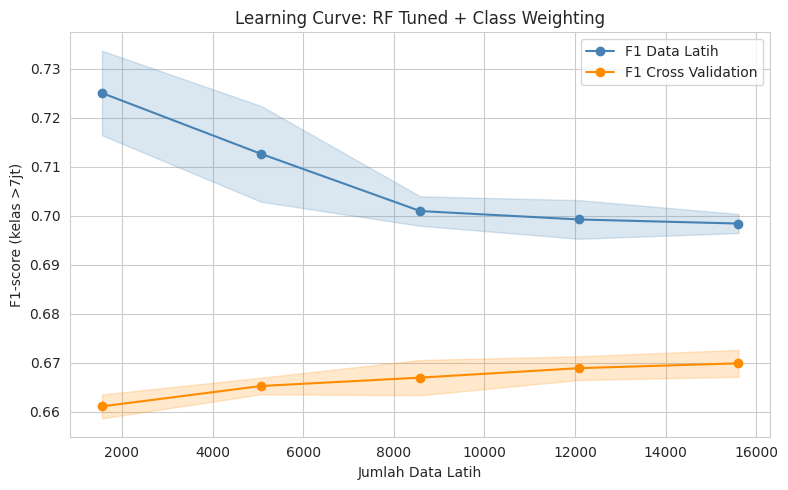

Ukuran data latih  : [ 1560  5071  8582 12093 15604]
F1 Train rata-rata : [0.725  0.7126 0.7009 0.6992 0.6984]
F1 CV rata-rata    : [0.6611 0.6653 0.667  0.6689 0.6699]

Gap tertinggi antara train dan CV: 0.0639


In [20]:
skf_lc = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    rf_tuned, X_train, y_train,
    cv=skf_lc, scoring='f1', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='F1 Data Latih')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='darkorange', label='F1 Cross Validation')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='darkorange')
plt.xlabel('Jumlah Data Latih')
plt.ylabel('F1-score (kelas >7jt)')
plt.title('Learning Curve: RF Tuned + Class Weighting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Ukuran data latih  :", train_sizes)
print("F1 Train rata-rata :", train_mean.round(4))
print("F1 CV rata-rata    :", val_mean.round(4))
print()
print("Gap tertinggi antara train dan CV:", round((train_mean - val_mean).max(), 4))

Learning curve menunjukkan pola yang sehat. Gap antara F1 data latih dan F1 cross validation paling besar pada ukuran data latih paling kecil (sekitar 0.06), lalu mengecil secara konsisten seiring bertambahnya data hingga sekitar 0.03 pada ukuran data penuh, dan tidak ada divergence yang signifikan. Ini mengindikasikan model tidak mengalami overfitting berat. Gap kecil yang masih tersisa mencerminkan sifat alami Random Forest yang cenderung sedikit lebih baik pada data yang sudah dilihatnya, namun perbedaannya masih dalam rentang yang wajar (Hastie et al., 2009).

## 14. Interpretasi Model dan Feature Importance

Selain melihat metrik performa, interpretasi model penting dilakukan untuk memahami fitur mana yang paling berkontribusi terhadap prediksi. Dua teknik digunakan pada bagian ini agar hasil interpretasi lebih robust, yaitu feature importance bawaan Random Forest (mean decrease in impurity) dan permutation importance yang dihitung langsung pada data uji.

### 13.1 Feature Importance Bawaan Random Forest (Mean Decrease in Impurity)

Random Forest secara native menyediakan ukuran feature importance berdasarkan penurunan rata-rata impuritas (mean decrease in impurity) di seluruh pohon. Fitur yang lebih sering dan efektif dipakai untuk memisahkan kelas mendapat skor importance yang lebih tinggi (Breiman, 2001). Perlu dicatat bahwa metode ini punya kelemahan, yaitu cenderung memberi skor lebih tinggi pada fitur kategorikal yang di-encode menjadi banyak kolom dummy melalui one-hot encoding, sehingga hasilnya perlu dibandingkan dengan teknik lain yang lebih netral terhadap jumlah kategori (Strobl et al., 2007).

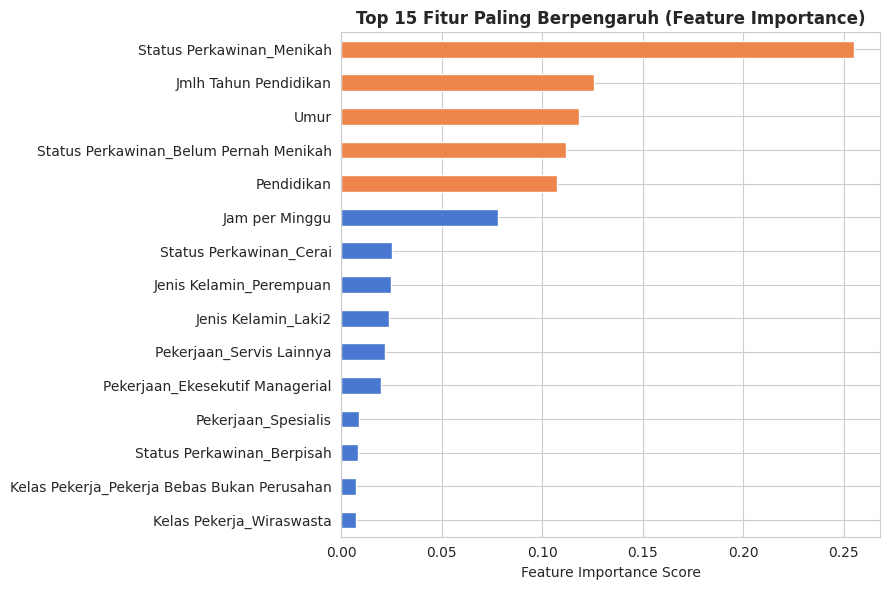

Top 10 feature importance:
Status Perkawinan_Menikah                 0.2554
Jmlh Tahun Pendidikan                     0.1259
Umur                                      0.1182
Status Perkawinan_Belum Pernah Menikah    0.1120
Pendidikan                                0.1072
Jam per Minggu                            0.0781
Status Perkawinan_Cerai                   0.0253
Jenis Kelamin_Perempuan                   0.0249
Jenis Kelamin_Laki2                       0.0238
Pekerjaan_Servis Lainnya                  0.0215


In [21]:
ohe_enc = rf_tuned.named_steps['prep'].named_transformers_['nominal'].named_steps['encoder']
nama_fitur = fitur_numerik + fitur_ordinal + list(ohe_enc.get_feature_names_out(fitur_nominal))

importances = pd.Series(
    rf_tuned.named_steps['model'].feature_importances_,
    index=nama_fitur
).sort_values(ascending=False)

top15 = importances.head(15)

plt.figure(figsize=(9, 6))
colors = ['#ee854a' if i < 5 else '#4878d0' for i in range(len(top15))]
top15.sort_values().plot(kind='barh', color=colors[::-1])
plt.title('Top 15 Fitur Paling Berpengaruh (Feature Importance)', fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 feature importance:")
print(top15.head(10).round(4).to_string())

Hasil feature importance mengungkap bahwa `Status Perkawinan_Menikah` adalah fitur tunggal yang paling berpengaruh dalam prediksi kategori gaji, jauh di atas fitur lainnya. Ini bukan tanpa alasan, karena status menikah dalam dataset ini berkorelasi kuat dengan usia dan tahap karir yang lebih matang, sehingga secara tidak langsung merepresentasikan pengalaman kerja. Fitur lain yang masuk top 5 adalah `Jmlh Tahun Pendidikan`, `Umur`, `Status Perkawinan_Belum Pernah Menikah`, dan `Pendidikan`, pola ini konsisten dengan temuan Kohavi (1996) pada dataset aslinya bahwa variabel demografis dan pendidikan adalah prediktor utama kategori pendapatan.

Untuk memvalidasi temuan ini dari sudut pandang yang berbeda, bagian selanjutnya menyajikan hasil permutation importance yang dihitung langsung dari penurunan performa model pada data uji, bukan dari proses pembentukan pohon.

### 14.2 Permutation Importance (Validasi Teknik Interpretasi Tambahan)

Sebagai pelengkap dan validasi terhadap feature importance bawaan Random Forest, permutation importance dihitung menggunakan `permutation_importance` dari `sklearn.inspection`. Teknik ini bekerja dengan cara mengacak (permutasi) nilai satu fitur secara acak sambil mempertahankan fitur lainnya tetap, lalu mengukur seberapa besar penurunan performa model akibat pengacakan tersebut. Fitur yang penting akan menyebabkan penurunan performa yang besar ketika diacak, sedangkan fitur yang tidak penting hampir tidak berpengaruh (Breiman, 2001).

Keunggulan permutation importance dibanding mean decrease in impurity adalah pengukurannya dilakukan pada fitur asli sebelum di-encode, bukan pada masing-masing kolom dummy hasil one-hot encoding. Dengan begitu, kontribusi satu variabel kategorikal seperti `Jenis Kelamin` atau `Status Perkawinan` diukur secara utuh sebagai satu fitur, sehingga hasilnya tidak bias terhadap variabel yang memiliki banyak kategori (Strobl et al., 2007).

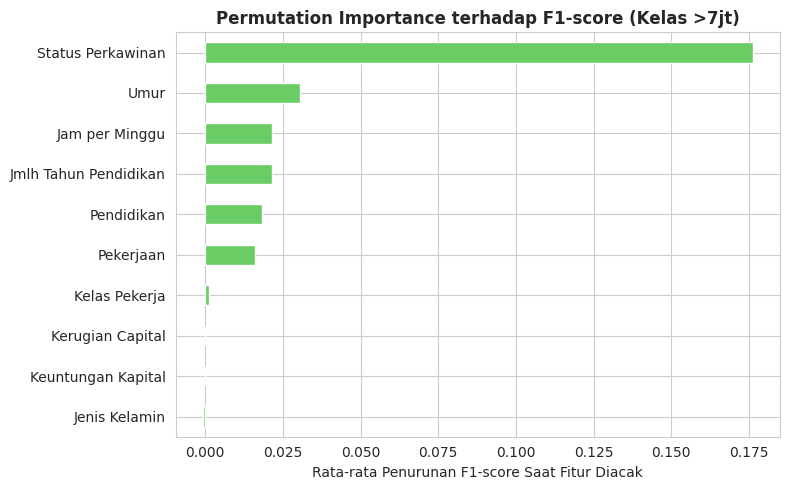

Permutation importance (diurutkan dari yang paling berpengaruh):
Status Perkawinan        0.1762
Umur                     0.0304
Jam per Minggu           0.0215
Jmlh Tahun Pendidikan    0.0215
Pendidikan               0.0183
Pekerjaan                0.0159
Kelas Pekerja            0.0013
Keuntungan Kapital       0.0000
Kerugian Capital         0.0000
Jenis Kelamin           -0.0007


In [22]:
perm_result = permutation_importance(
    rf_tuned, X_test, y_test,
    n_repeats=10, random_state=42, scoring='f1', n_jobs=-1
)

perm_importance = pd.Series(
    perm_result.importances_mean, index=X_test.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind='barh', color='#6acc65')
plt.title('Permutation Importance terhadap F1-score (Kelas >7jt)', fontsize=12, fontweight='bold')
plt.xlabel('Rata-rata Penurunan F1-score Saat Fitur Diacak')
plt.tight_layout()
plt.show()

print("Permutation importance (diurutkan dari yang paling berpengaruh):")
print(perm_importance.round(4).to_string())

Hasil permutation importance mengonfirmasi `Status Perkawinan` sebagai fitur paling berpengaruh, konsisten dengan hasil mean decrease in impurity sebelumnya. Namun ada temuan menarik: `Jenis Kelamin`, yang sebelumnya masuk top 10 pada feature importance bawaan karena terpecah menjadi dua kolom dummy (`Jenis Kelamin_Laki2` dan `Jenis Kelamin_Perempuan`), ternyata memiliki kontribusi yang mendekati nol bahkan sedikit negatif terhadap F1-score ketika diukur sebagai satu variabel utuh melalui permutation importance. Begitu pula `Keuntungan Kapital` dan `Kerugian Capital` yang kontribusinya nyaris nol. Temuan ini menunjukkan bahwa perbandingan dua teknik interpretasi memberikan gambaran yang lebih lengkap dan menghindari kesimpulan yang keliru akibat bias mean decrease in impurity terhadap fitur dengan banyak kategori (Strobl et al., 2007). Kesimpulan praktisnya, `Jenis Kelamin` bisa dipertimbangkan untuk dikeluarkan dari model pada iterasi berikutnya tanpa mengorbankan performa, sekaligus mengurangi risiko bias fairness pada model.

### 14.3 SHAP (SHapley Additive exPlanations)

Feature importance bawaan Random Forest dan permutation importance pada bagian sebelumnya keduanya hanya memberikan interpretasi pada level global, yaitu seberapa penting suatu fitur secara rata-rata di seluruh data. Keduanya tidak dapat menjelaskan mengapa satu individu tertentu diprediksi masuk kategori `>7jt` sementara individu lain dengan sedikit perbedaan atribut diprediksi sebaliknya. SHAP (Lundberg & Lee, 2017) mengatasi keterbatasan ini dengan menghitung kontribusi tiap fitur terhadap prediksi pada level individual, berdasarkan konsep nilai Shapley dari teori permainan kooperatif, sekaligus tetap dapat diagregasi untuk memberikan gambaran global yang konsisten dengan dua teknik sebelumnya.

`TreeExplainer` digunakan karena dioptimalkan khusus untuk model berbasis pohon seperti Random Forest, sehingga perhitungan nilai SHAP menjadi jauh lebih efisien secara komputasi dibanding metode SHAP generik (KernelExplainer). Mengingat perhitungan SHAP tetap cukup berat untuk dijalankan pada seluruh data uji, perhitungan dilakukan pada subsample sebanyak 300 baris data uji yang diambil secara acak, sebuah praktik umum yang tidak mengurangi validitas kesimpulan global karena ukuran subsample tersebut sudah cukup besar untuk mengestimasi pola rata-rata secara stabil.


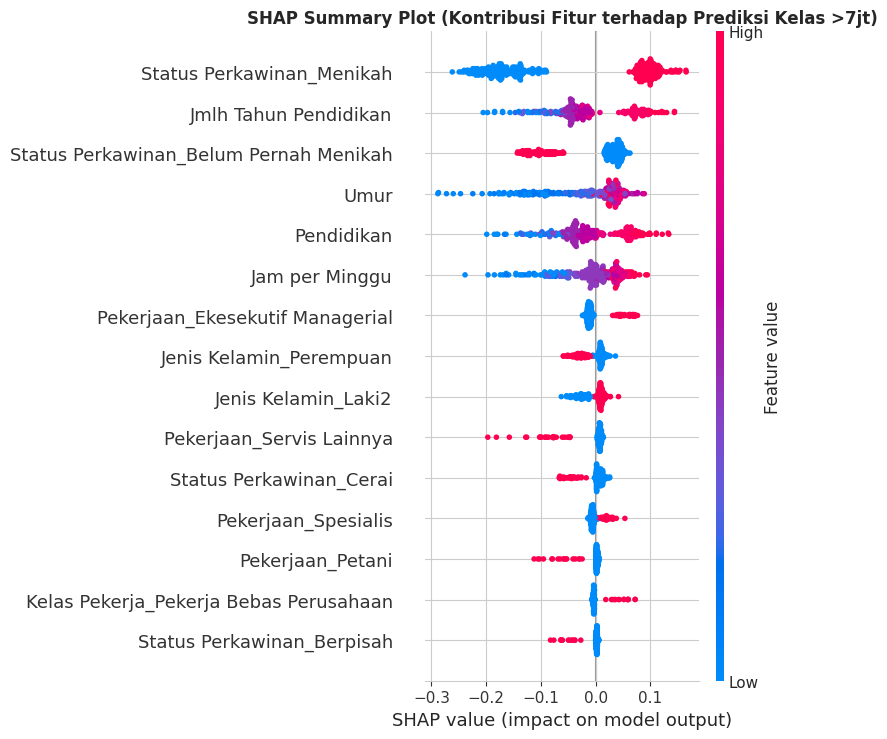

In [23]:
import shap

X_test_transformed = rf_tuned.named_steps['prep'].transform(X_test)
if hasattr(X_test_transformed, 'toarray'):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed = pd.DataFrame(X_test_transformed, columns=nama_fitur)

np.random.seed(42)
sample_idx = np.random.choice(X_test_transformed.shape[0], size=300, replace=False)
X_shap_sample = X_test_transformed.iloc[sample_idx]

explainer = shap.TreeExplainer(rf_tuned.named_steps['model'])
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values_kelas1 = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_kelas1 = shap_values[:, :, 1]
else:
    shap_values_kelas1 = shap_values

shap.summary_plot(shap_values_kelas1, X_shap_sample, show=False, max_display=15)
plt.title('SHAP Summary Plot (Kontribusi Fitur terhadap Prediksi Kelas >7jt)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


SHAP summary plot di atas menunjukkan bahwa `Status Perkawinan_Menikah` memiliki rata-rata nilai |SHAP| tertinggi (0.1389), jauh di atas fitur lain, konsisten dengan dua teknik interpretasi sebelumnya (feature importance bawaan dan permutation importance). Fitur berikutnya secara berurutan adalah `Jmlh Tahun Pendidikan` (0.0585), `Status Perkawinan_Belum Pernah Menikah` (0.0562), `Umur` (0.0557), dan `Pendidikan` (0.0495). Konsistensi urutan fitur teratas di ketiga teknik interpretasi yang berbeda prinsip kerja (impurity-based, permutation-based, dan Shapley value-based) memperkuat keyakinan bahwa dominasi status perkawinan bukan artefak dari satu metode pengukuran tertentu, melainkan pola yang benar-benar kuat dalam data.


Contoh interpretasi lokal untuk satu individu pada data uji:
Probabilitas prediksi kelas >7jt: 0.5349
Prediksi akhir: >7jt



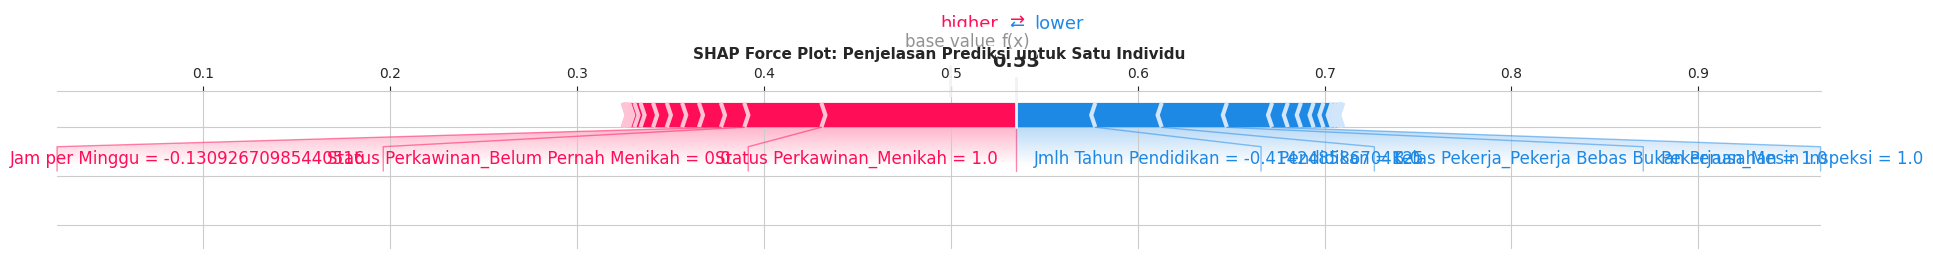

In [24]:
contoh_idx = 0
contoh_data = X_shap_sample.iloc[[contoh_idx]]
pred_contoh = rf_tuned.named_steps['model'].predict_proba(contoh_data)[0, 1]

print(f"Contoh interpretasi lokal untuk satu individu pada data uji:")
print(f"Probabilitas prediksi kelas >7jt: {pred_contoh:.4f}")
print(f"Prediksi akhir: {'>7jt' if pred_contoh >= 0.5 else '<=7jt'}\n")

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and len(np.shape(expected_value)) > 0 and np.shape(expected_value)[0] > 1:
    expected_value = expected_value[1]

shap.force_plot(
    expected_value,
    shap_values_kelas1[contoh_idx],
    contoh_data,
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot: Penjelasan Prediksi untuk Satu Individu', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


Force plot di atas menunjukkan bagaimana tiap fitur mendorong prediksi satu individu contoh menjauh dari nilai basis (expected value/rata-rata prediksi seluruh data) menuju probabilitas akhir sebesar 0.5349, yang berujung pada klasifikasi `>7jt`. Warna merah merepresentasikan fitur yang mendorong prediksi ke arah kelas `>7jt`, sedangkan warna biru mendorong ke arah sebaliknya. Inilah keunggulan utama SHAP dibanding feature importance maupun permutation importance, karena penjelasan pada level individual seperti ini dapat digunakan untuk menjawab pertanyaan spesifik semacam "mengapa pekerja ini diprediksi berpendapatan tinggi", yang sangat relevan apabila model digunakan untuk mendukung keputusan pada kasus per kasus, bukan sekadar analisis agregat.


## 15. Perbandingan Lengkap Lima Model

Bagian ini merangkum perbandingan ketiga model yang dibangun dalam satu tabel dan satu visualisasi, untuk memudahkan pembacaan kontribusi masing-masing tahap yang dilakukan dalam penelitian ini.

In [25]:
hasil_perbandingan = pd.DataFrame({
    'Model': ['RF Baseline (tanpa weighting)', 'RF + Class Weighting (balanced)',
              'RF Tuned + Class Weighting (model utama)', 'Logistic Regression + Class Weighting',
              'XGBoost + scale_pos_weight'],
    'Accuracy': [
        accuracy_score(y_test, pred_baseline), accuracy_score(y_test, pred_weighted),
        accuracy_score(y_test, pred_tuned), accuracy_score(y_test, pred_logreg),
        accuracy_score(y_test, pred_xgb)
    ],
    'Precision (>7jt)': [
        precision_score(y_test, pred_baseline), precision_score(y_test, pred_weighted),
        precision_score(y_test, pred_tuned), precision_score(y_test, pred_logreg),
        precision_score(y_test, pred_xgb)
    ],
    'Recall (>7jt)': [
        recall_score(y_test, pred_baseline), recall_score(y_test, pred_weighted),
        recall_score(y_test, pred_tuned), recall_score(y_test, pred_logreg),
        recall_score(y_test, pred_xgb)
    ],
    'F1 (>7jt)': [
        f1_score(y_test, pred_baseline), f1_score(y_test, pred_weighted),
        f1_score(y_test, pred_tuned), f1_score(y_test, pred_logreg),
        f1_score(y_test, pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, prob_baseline), roc_auc_score(y_test, prob_weighted),
        roc_auc_score(y_test, prob_tuned), roc_auc_score(y_test, prob_logreg),
        roc_auc_score(y_test, prob_xgb)
    ]
}).round(4)

hasil_perbandingan.set_index('Model', inplace=True)
hasil_perbandingan


,Accuracy,Precision (>7jt),Recall (>7jt),F1 (>7jt),ROC-AUC
Model,,,,,
RF Baseline (tanpa weighting),0.7693,0.5671,0.5020,0.5325,0.8241
RF + Class Weighting (balanced),0.7722,0.5692,0.5339,0.5510,0.8240
RF Tuned + Class Weighting (model utama),0.7854,0.5630,0.8048,0.6625,0.8732
Logistic Regression + Class Weighting,0.7758,0.5492,0.8022,0.6520,0.8646
XGBoost + scale_pos_weight,0.7869,0.5645,0.8140,0.6667,0.8720


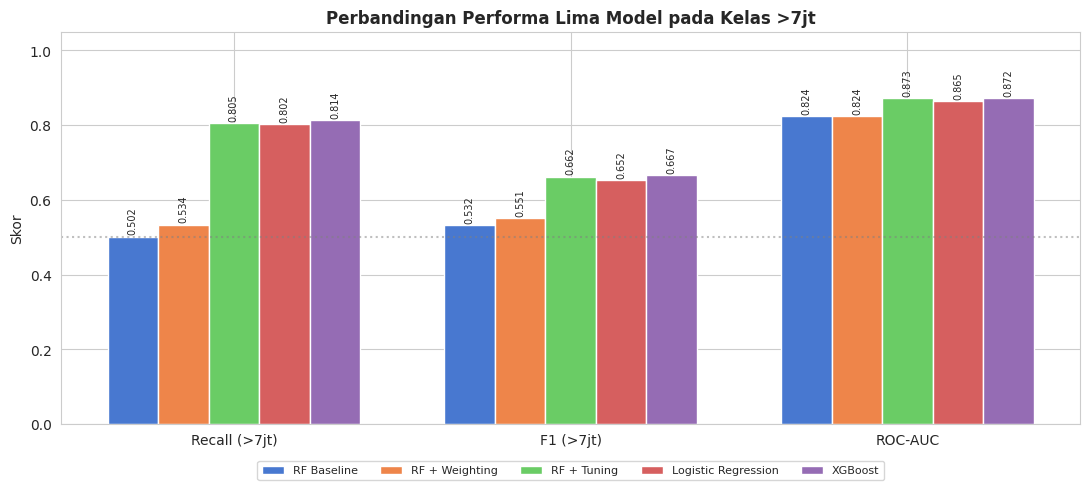

In [26]:
metrik_plot = ['Recall (>7jt)', 'F1 (>7jt)', 'ROC-AUC']
x = np.arange(len(metrik_plot))
width = 0.15
labels_singkat = ['RF Baseline', 'RF + Weighting', 'RF + Tuning', 'Logistic Regression', 'XGBoost']
colors_model = ['#4878d0', '#ee854a', '#6acc65', '#d65f5f', '#956cb4']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (label, color) in enumerate(zip(labels_singkat, colors_model)):
    vals = [hasil_perbandingan.loc[hasil_perbandingan.index[i], m] for m in metrik_plot]
    rects = ax.bar(x + i*width - 2*width, vals, width, label=label, color=color)
    for r in rects:
        ax.text(r.get_x() + r.get_width()/2, r.get_height() + 0.005, f'{r.get_height():.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_ylabel('Skor')
ax.set_title('Perbandingan Performa Lima Model pada Kelas >7jt', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrik_plot)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


Tabel dan visualisasi di atas merangkum perjalanan peningkatan performa Random Forest secara bertahap, sekaligus posisinya relatif terhadap dua keluarga algoritma pembanding. Penambahan class weighting pada model kedua mengangkat recall kelas `>7jt` dan F1-score dibanding baseline. Model utama dengan tambahan hyperparameter tuning memberi lonjakan paling signifikan, terutama pada recall (dari sekitar 0.50 di baseline ke 0.80 di model utama) dan ROC-AUC (dari 0.82 ke 0.87). Dibandingkan dua model dari keluarga algoritma berbeda, Logistic Regression (linear) dan XGBoost (gradient boosting), RF Tuned tetap kompetitif, dengan XGBoost unggul tipis pada recall dan F1, sementara Logistic Regression unggul tipis hanya pada recall. Secara keseluruhan, ketiga model hasil penanganan class imbalance (RF Tuned, Logistic Regression, XGBoost) memiliki performa yang sebanding, jauh di atas RF Baseline dan RF + Weighting, yang mengonfirmasi bahwa class weighting dan/atau scale_pos_weight adalah faktor yang jauh lebih menentukan performa pada kelas minoritas dibanding pemilihan keluarga algoritma itu sendiri.


## 16. Menyimpan Model

Model utama dan preprocessor disimpan dalam format `.pkl` menggunakan `joblib` agar dapat dipanggil kembali untuk inferensi tanpa perlu training ulang.

In [27]:
os.makedirs('model', exist_ok=True)
joblib.dump(rf_baseline, 'model/rf_baseline.pkl')
joblib.dump(rf_weighted, 'model/rf_weighted.pkl')
joblib.dump(rf_tuned, 'model/rf_tuned_main.pkl')
joblib.dump(logreg, 'model/logreg_pembanding.pkl')
joblib.dump(xgb_model, 'model/xgb_pembanding.pkl')
joblib.dump(preprocessor, 'model/preprocessor.pkl')

print("Semua model berhasil disimpan:")
for f in os.listdir('model'):
    size_kb = os.path.getsize(f'model/{f}') / 1024
    print(f"  model/{f} ({size_kb:.1f} KB)")


Semua model berhasil disimpan:
  model/rf_tuned_main.pkl (16464.3 KB)
  model/rf_weighted.pkl (79717.1 KB)
  model/xgb_pembanding.pkl (667.0 KB)
  model/rf_baseline.pkl (76660.6 KB)
  model/logreg_pembanding.pkl (6.8 KB)
  model/preprocessor.pkl (5.8 KB)


In [28]:
# Verifikasi model bisa dipanggil ulang dan memberi prediksi
model_reload = joblib.load('model/rf_tuned_main.pkl')
contoh_input = X_test.iloc[:5]
prediksi = model_reload.predict(contoh_input)
probabilitas = model_reload.predict_proba(contoh_input)[:, 1]

hasil_demo = pd.DataFrame({
    'Prediksi kelas': ['<=7jt' if p == 0 else '>7jt' for p in prediksi],
    'Probabilitas >7jt': probabilitas.round(3),
    'Label aktual': ['<=7jt' if a == 0 else '>7jt' for a in y_test.iloc[:5].values]
})
print("Contoh inferensi dari model yang dimuat ulang:")
hasil_demo

Contoh inferensi dari model yang dimuat ulang:


,Prediksi kelas,Probabilitas >7jt,Label aktual
0,>7jt,0.664,>7jt
1,<=7jt,0.033,<=7jt
2,<=7jt,0.037,<=7jt
3,>7jt,0.808,<=7jt
4,>7jt,0.612,<=7jt


## 17. Kesimpulan

Penelitian ini membangun sistem klasifikasi kategori gaji pekerja pada dataset yang memiliki ketidakseimbangan kelas, dengan membandingkan lima model dari tiga keluarga algoritma berbeda, yaitu Random Forest (ensemble bagging, tiga varian), Logistic Regression (linear model, satu varian), dan XGBoost (ensemble boosting, satu varian), untuk memastikan perbandingan performa tidak hanya terbatas pada satu jenis algoritma saja.

Dari tiga varian Random Forest yang dibangun dan dievaluasi, model utama yaitu Random Forest dengan kombinasi class weighting `balanced` dan hyperparameter hasil `RandomizedSearchCV` (`n_estimators=200`, `max_depth=15`, `min_samples_leaf=5`, `min_samples_split=10`, `max_features='log2'`) memberikan performa terbaik di antara ketiga varian Random Forest pada metrik yang relevan untuk kondisi data tidak seimbang. Recall kelas `>7jt` mencapai 0.8048, naik signifikan dibanding baseline yang hanya 0.5020. F1-score kelas `>7jt` naik dari 0.5325 ke 0.6625, dan ROC-AUC meningkat dari 0.8241 ke 0.8732. Stabilitas performa ini turut dikonfirmasi lewat validasi silang 5-fold, dengan F1-score rata-rata 0.6699 (standar deviasi 0.0058) dan ROC-AUC rata-rata 0.8774 (standar deviasi 0.0030) di seluruh fold.

Sebagai pembanding dari dua keluarga algoritma yang berbeda, Logistic Regression dan XGBoost, keduanya menggunakan mekanisme penanganan imbalance yang setara (class weighting dan scale_pos_weight). Logistic Regression menghasilkan recall kelas `>7jt` sebesar 0.8022, hampir setara dengan RF Tuned, namun precision (0.5492), F1-score (0.6520), dan ROC-AUC (0.8646) nya sedikit di bawah RF Tuned. XGBoost bahkan sedikit unggul pada recall (0.8140) dan F1-score (0.6667) dibanding RF Tuned, dengan ROC-AUC yang hampir identik (0.8720 berbanding 0.8732). Temuan ini menunjukkan bahwa ketiga model yang sudah ditangani ketidakseimbangan kelasnya (RF Tuned, Logistic Regression, XGBoost) berada pada level performa yang sebanding, dan Random Forest tetap dipilih sebagai model utama bukan karena selisih performa yang signifikan, melainkan karena kesederhanaan interpretasi dan kestabilan hyperparameter dibanding XGBoost yang lebih sensitif terhadap learning_rate.

Berdasarkan tiga teknik interpretasi yang saling melengkapi, yaitu feature importance bawaan Random Forest, permutation importance, dan SHAP, `Status Perkawinan` kategori Menikah konsisten menjadi faktor paling dominan dalam penentuan kategori gaji di ketiganya, diikuti oleh `Jmlh Tahun Pendidikan` dan `Umur`, konsisten dengan temuan studi serupa pada dataset UCI Adult (Kohavi, 1996). Perbandingan feature importance bawaan dengan permutation importance juga mengungkap bahwa `Jenis Kelamin` yang tampak penting pada feature importance bawaan ternyata nyaris tidak berkontribusi ketika diukur secara utuh, sebuah temuan yang konsisten dengan kritik Strobl et al. (2007) terhadap bias mean decrease in impurity pada fitur kategorikal dengan banyak kategori dummy. SHAP melengkapi kedua teknik tersebut dengan kemampuan menjelaskan prediksi pada level individual (Lundberg & Lee, 2017), yang berguna untuk menjawab pertanyaan spesifik mengenai kasus per kasus, bukan sekadar pola rata-rata di seluruh data.

Secara keseluruhan, hasil ini mengonfirmasi bahwa penanganan ketidakseimbangan kelas melalui class weighting atau scale_pos_weight adalah langkah yang esensial, bukan opsional, dalam membangun model klasifikasi yang adil dan berguna pada data dengan distribusi kelas yang tidak merata, dan bahwa kesimpulan ini tetap konsisten di tiga keluarga algoritma yang berbeda. Tuning hyperparameter yang sistematis melalui `RandomizedSearchCV`, validasi lewat cross validation dan learning curve, perbandingan lintas keluarga algoritma, serta interpretasi model lewat tiga teknik yang saling melengkapi, secara bersama-sama membuat kesimpulan yang diambil pada penelitian ini jauh lebih kredibel dibanding hanya mengandalkan satu metrik, satu algoritma, atau satu teknik interpretasi saja.

---

## Daftar Pustaka

Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, 13(10), 281-305.

Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5-32. https://doi.org/10.1023/A:1010933404324

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321-357. https://doi.org/10.1613/jair.953

Chen, C., Liaw, A., & Breiman, L. (2004). Using random forest to learn imbalanced data. Technical Report 666, Department of Statistics, University of California, Berkeley.

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263-1284. https://doi.org/10.1109/TKDE.2008.239

Kohavi, R. (1996). Scaling up the accuracy of Naive-Bayes classifiers: A decision-tree hybrid. *Proceedings of the Second International Conference on Knowledge Discovery and Data Mining*, 202-207.

Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of IJCAI*, 14(2), 1137-1145.

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems*, 30, 4765-4774.

Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures: Illustrations, sources and a solution. *BMC Bioinformatics*, 8, 25. https://doi.org/10.1186/1471-2105-8-25
